# Сравнение contrastive-лоссов (v2): infonce / infonce_hn / triplet / mnr_softmax

**Цель.** Сравнить 4 contrastive loss-функции при одинаковых данных, моделях и бюджете обучения.

**Изменения v2 по сравнению с v1:**
- **Qwen3-Embedding-4B** (не 0.6B) — совпадает со Stage B/Stage C чекпойнтами.
- `last_token_pool` с **корректной поддержкой left-padding** (как в работающем Stage B).
- `_detect_lora_targets` — той же сигнатуры, с fallback на `output.dense`.
- **Отдельная ячейка baseline'ов** для трёх моделей через `mode="frozen"`.
- **Early stopping убран**: все эпохи отрабатывают полностью; лучший снэпшот по `val_stsb` сохраняется для финальной оценки.

**Loss-функции:** `infonce`, `infonce_hn`, `triplet`, `mnr_softmax` (всё через одну `GradientCache`).

**Данные:** `ru_paraphraser class==1` (~1.8k) + `cointegrated/nli-rus-translated-v2021` label=entailment (~8.2k) ≈ 10k positive pairs. Hard negatives: NLI contradiction + paraphraser class∈{0,−1}.

**Бюджет:** 2 эпохи × 10k pairs × 4 loss × 3 модели = 24 прохода данных.

In [ ]:
# !pip uninstall -y torch torchvision torchaudio torchao
# !pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu121
# !pip install -U "transformers>=4.40" "datasets>=2.18" "peft==0.12.0" "accelerate" "scipy" "tqdm"

In [ ]:
# 1. Install
import sys, subprocess
def pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])
try:
    import torch, transformers, datasets, peft, scipy
except Exception:
    pip("torch", "transformers>=4.40", "datasets>=2.18",
        "peft>=0.9", "accelerate", "scipy", "tqdm", "matplotlib", "pandas")


In [ ]:
# 2. Imports + config
import os, gc as _gc, json, math, random, warnings, time
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict, TaskType

import matplotlib.pyplot as plt

# Plot style — как в работающем Stage B
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 14,
})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

CKPT_DIR = "./checkpoints_loss_compare"
HIST_DIR = "./histories_loss_compare"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(HIST_DIR, exist_ok=True)

USE_DORA = True

def free_gpu():
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize(); torch.cuda.empty_cache()


device: cuda
gpu: NVIDIA A100-SXM4-80GB


In [ ]:
# 3. STS eval data + metric (PhilipMay/stsb_multi_mt — как в работающем коде)
def sts_quality(gold, pred):
    p = pearsonr(gold, pred).statistic
    s = spearmanr(gold, pred).statistic
    return (p + s) / 2.0

print("Loading STSBenchmark-ru (PhilipMay/stsb_multi_mt) ...")
stsb = load_dataset("PhilipMay/stsb_multi_mt", "ru")
val_stsb_pairs  = [(r["sentence1"], r["sentence2"], float(r["similarity_score"]))
                   for r in stsb["dev"]]
test_stsb_pairs = [(r["sentence1"], r["sentence2"], float(r["similarity_score"]))
                   for r in stsb["test"]]

print("Loading STS22-ru ...")
sts22 = load_dataset("mteb/sts22-crosslingual-sts", "ru")
test_sts22_pairs = [(r["sentence1"], r["sentence2"], float(r["score"]))
                    for r in sts22["test"]]

print(f"val_stsb={len(val_stsb_pairs)} test_stsb={len(test_stsb_pairs)} test_sts22={len(test_sts22_pairs)}")


Loading STSBenchmark-ru (PhilipMay/stsb_multi_mt) ...


Loading STS22-ru ...
val_stsb=1500 test_stsb=1379 test_sts22=265


In [ ]:
# 4. Training corpus: paraphrases (class==1) + NLI entailment + contradictions

def _n(t):
    if t is None: return ""
    return " ".join(str(t).split()).strip()

print("Loading merionum/ru_paraphraser ...")
ds_par = load_dataset("merionum/ru_paraphraser", split="train", trust_remote_code=True)
par_pos = []
par_neg = []
for r in ds_par:
    a = _n(r.get("text_1")); b = _n(r.get("text_2"))
    cl = r.get("class")
    try: cl = int(cl)
    except Exception: continue
    if not a or not b: continue
    if cl == 1:
        par_pos.append((a, b))
    elif cl in (0, -1):
        par_neg.append((a, b))
print(f"  paraphrase positives (class==1): {len(par_pos):,}")
print(f"  paraphrase negatives (class in {{0,-1}}): {len(par_neg):,}")

print("Loading cointegrated/nli-rus-translated-v2021 ...")
ds_nli = load_dataset("cointegrated/nli-rus-translated-v2021", split="train")
premise_to_ent = {}; premise_to_con = {}
for r in ds_nli:
    lab = r.get("label", "")
    a = _n(r.get("premise_ru")); b = _n(r.get("hypothesis_ru"))
    if not a or not b: continue
    if len(a) < 3 or len(b) < 3: continue
    if lab == "entailment":
        premise_to_ent.setdefault(a, []).append(b)
    elif lab == "contradiction":
        premise_to_con.setdefault(a, []).append(b)
print(f"  NLI premises w/ entailment:    {len(premise_to_ent):,}")
print(f"  NLI premises w/ contradiction: {len(premise_to_con):,}")

rng = np.random.default_rng(SEED)
need_from_nli = max(0, MAX_PAIRS - len(par_pos))
keys = list(premise_to_ent.keys()); rng.shuffle(keys)
nli_positives = []
for prem in keys:
    if len(nli_positives) >= need_from_nli: break
    hyp = rng.choice(premise_to_ent[prem])
    nli_positives.append((prem, hyp))

items = []
for (a, b) in par_pos:
    items.append({"a": a, "b": b, "src": "par"})
for (a, b) in nli_positives:
    items.append({"a": a, "b": b, "src": "nli"})
rng.shuffle(items)
items = items[:MAX_PAIRS]

# Hard-negative pools
par_neg_idx = {}
for a, b in par_neg:
    par_neg_idx.setdefault(a, []).append(b)
    par_neg_idx.setdefault(b, []).append(a)
flat_par_neg = [t for pair in par_neg for t in pair]

for it in items:
    pool = []
    if it["src"] == "nli":
        pool.extend(premise_to_con.get(it["a"], []))
    else:
        pool.extend(par_neg_idx.get(it["a"], []))
        pool.extend(par_neg_idx.get(it["b"], []))
    if len(pool) == 0 and len(flat_par_neg) > 0:
        pool.append(flat_par_neg[rng.integers(0, len(flat_par_neg))])
    pool = [p for p in pool if p and p != it["a"] and p != it["b"]]
    pool = list(dict.fromkeys(pool))[:8]
    it["hn_pool"] = pool

n_par = sum(1 for it in items if it["src"] == "par")
n_nli = sum(1 for it in items if it["src"] == "nli")
n_hn  = sum(1 for it in items if len(it["hn_pool"]) > 0)
print(f"\nFinal training corpus: {len(items):,} pairs (par={n_par}, nli={n_nli}); "
      f"with hard-neg pool: {n_hn:,}")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'merionum/ru_paraphraser' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'merionum/ru_paraphraser' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading merionum/ru_paraphraser ...
  paraphrase positives (class==1): 1,688
  paraphrase negatives (class in {0,-1}): 5,539
Loading cointegrated/nli-rus-translated-v2021 ...


Generating train split:   0%|          | 0/1756548 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/106557 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/34615 [00:00<?, ? examples/s]

  NLI premises w/ entailment:    428,399
  NLI premises w/ contradiction: 318,513

Final training corpus: 10,000 pairs (par=1688, nli=8312); with hard-neg pool: 9,992


In [ ]:
# 5. STSEncoder — aligned with working Stage B implementation

E5_INSTRUCT_TASK   = "Given a text, retrieve relevant passages"
QWEN_INSTRUCT_TASK = "Retrieve semantically similar text"

def _detect_lora_targets(model) -> List[str]:
    names = {n for n, _ in model.named_modules()}
    if any(".q_proj" in n for n in names):
        return ["q_proj", "k_proj", "v_proj", "o_proj"]
    return ["query", "key", "value", "output.dense"]

def last_token_pool(h, attention_mask):
    # Left-padding aware: для Qwen с padding_side='left' все реальные токены сдвинуты вправо,
    # поэтому если в последней позиции все 1 — это left-padded батч, берем -1.
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return h[:, -1]
    seq_lens = attention_mask.sum(dim=1) - 1
    bs = h.size(0)
    return h[torch.arange(bs, device=h.device), seq_lens]

@dataclass
class ModelSpec:
    name: str
    model_id: str
    pooling: str           # "cls" | "mean" | "last"
    prompt: str            # "none" | "e5_instruct" | "qwen_instruct"
    is_qwen: bool = False
    dtype: torch.dtype = torch.float32
    max_length: int = 192
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1

class STSEncoder(nn.Module):
    def __init__(self, spec: ModelSpec, mode: str = "lora", use_dora: bool = True):
        super().__init__()
        self.spec = spec
        self.tokenizer = AutoTokenizer.from_pretrained(
            spec.model_id, use_fast=True,
            padding_side="left" if spec.is_qwen else "right",
            trust_remote_code=True,
        )
        kw = {"trust_remote_code": True}
        if spec.dtype != torch.float32:
            kw["torch_dtype"] = spec.dtype
        base = AutoModel.from_pretrained(spec.model_id, **kw)

        if mode == "lora":
            targets = _detect_lora_targets(base)
            cfg_kwargs = dict(r=spec.lora_r, lora_alpha=spec.lora_alpha,
                              lora_dropout=spec.lora_dropout, bias="none",
                              target_modules=targets,
                              task_type=TaskType.FEATURE_EXTRACTION)
            if use_dora:
                try:
                    cfg = LoraConfig(**cfg_kwargs, use_dora=True)
                except TypeError:
                    cfg = LoraConfig(**cfg_kwargs)
                    print(f"  [warn] DoRA not supported, falling back to LoRA")
            else:
                cfg = LoraConfig(**cfg_kwargs)
            self.model = get_peft_model(base, cfg)
        elif mode == "frozen":
            self.model = base
            for p in self.model.parameters(): p.requires_grad = False
        else:
            self.model = base

    def trainable_params(self):
        n_tr  = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        n_tot = sum(p.numel() for p in self.model.parameters())
        return n_tr, n_tot

    def _prep(self, texts):
        if self.spec.prompt == "e5_instruct":
            return [f"Instruct: {E5_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        elif self.spec.prompt == "qwen_instruct":
            return [f"Instruct: {QWEN_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        return list(texts)

    def forward(self, texts):
        texts = self._prep(texts)
        tok = self.tokenizer(texts, padding=True, truncation=True,
                             max_length=self.spec.max_length, return_tensors="pt").to(device)
        out = self.model(**tok)
        h = out.last_hidden_state
        if self.spec.pooling == "cls":
            emb = h[:, 0]
        elif self.spec.pooling == "last":
            emb = last_token_pool(h, tok["attention_mask"])
        else:
            attn = tok["attention_mask"].unsqueeze(-1).float()
            emb  = (h * attn).sum(1) / attn.sum(1).clamp(min=1e-6)
        return F.normalize(emb.float(), p=2, dim=-1)

    @torch.no_grad()
    def encode(self, texts, batch_size: int = 64, to_cpu: bool = True):
        was = self.training; self.eval()
        embs = []
        for i in range(0, len(texts), batch_size):
            e = self.forward(texts[i:i+batch_size]).detach()
            embs.append(e.cpu() if to_cpu else e)
        self.train(was)
        return torch.cat(embs, 0)

def snap(model: STSEncoder):
    sd = get_peft_model_state_dict(model.model)
    return {k: v.detach().clone().cpu() for k, v in sd.items()}

def restore(model: STSEncoder, snapshot):
    set_peft_model_state_dict(model.model, {k: v.to(device) for k, v in snapshot.items()})


In [ ]:
# 6. STS eval helpers (используют STSEncoder.encode — единое место)
def eval_sts(m: STSEncoder, pairs, batch_size: int = 64) -> float:
    a = [p[0] for p in pairs]; b = [p[1] for p in pairs]
    g = np.array([p[2] for p in pairs], dtype=np.float32)
    ea = m.encode(a, batch_size=batch_size, to_cpu=True)
    eb = m.encode(b, batch_size=batch_size, to_cpu=True)
    s = (ea * eb).sum(-1).numpy()
    return float(sts_quality(g, s))

def full_eval(m: STSEncoder, batch_size: int = 64) -> Dict[str, float]:
    return {
        "val_stsb":   eval_sts(m, val_stsb_pairs, batch_size),
        "test_stsb":  eval_sts(m, test_stsb_pairs, batch_size),
        "test_sts22": eval_sts(m, test_sts22_pairs, batch_size),
    }


In [ ]:
# 7. Loss-функции — 4 варианта

def loss_infonce(U, V, HN=None, tau=0.05, **_):
    # Symmetric InfoNCE on (U, V) with in-batch negatives only.
    sim = (U @ V.T) / tau
    target = torch.arange(U.size(0), device=U.device)
    return 0.5 * (F.cross_entropy(sim, target) + F.cross_entropy(sim.T, target))

def loss_mnr_softmax(U, V, HN=None, tau=0.05, **_):
    # Non-symmetric MultipleNegativesRanking: U -> V direction only.
    sim = (U @ V.T) / tau
    target = torch.arange(U.size(0), device=U.device)
    return F.cross_entropy(sim, target)

def loss_infonce_hn(U, V, HN=None, tau=0.05, **_):
    # Symmetric InfoNCE + explicit HN added to row-direction and global to col-direction.
    B, d = U.shape
    sim_uv = (U @ V.T) / tau
    target = torch.arange(B, device=U.device)
    if HN is None or HN.numel() == 0:
        return 0.5 * (F.cross_entropy(sim_uv, target) + F.cross_entropy(sim_uv.T, target))
    assert HN.size(0) == B and HN.size(-1) == d, f"HN shape {tuple(HN.shape)} vs U {tuple(U.shape)}"
    K = HN.size(1)
    sim_uh = torch.einsum('bd,bkd->bk', U, HN) / tau
    logits_row = torch.cat([sim_uv, sim_uh], dim=1)
    loss_row = F.cross_entropy(logits_row, target)
    HN_flat = HN.reshape(B * K, d)
    sim_vh = (V @ HN_flat.T) / tau
    logits_col = torch.cat([sim_uv.T, sim_vh], dim=1)
    loss_col = F.cross_entropy(logits_col, target)
    return 0.5 * (loss_row + loss_col)

def loss_triplet(U, V, HN=None, tau=0.05, margin=0.2, **_):
    # Margin triplet with one explicit hard negative per anchor (max sim across K), or hardest in-batch.
    B, d = U.shape
    pos_sim = (U * V).sum(-1)
    if HN is not None and HN.numel() > 0:
        assert HN.size(0) == B and HN.size(-1) == d
        sim_uh = torch.einsum('bd,bkd->bk', U, HN)
        neg_sim, _ = sim_uh.max(dim=1)
    else:
        sim_all = U @ V.T
        mask = torch.eye(B, dtype=torch.bool, device=U.device)
        sim_all = sim_all.masked_fill(mask, -1e9)
        neg_sim, _ = sim_all.max(dim=1)
    return F.relu(margin - pos_sim + neg_sim).mean()

LOSS_FNS = {
    "infonce":     loss_infonce,
    "infonce_hn":  loss_infonce_hn,
    "triplet":     loss_triplet,
    "mnr_softmax": loss_mnr_softmax,
}
USES_HN = {"infonce": False, "infonce_hn": True, "triplet": True, "mnr_softmax": False}
print("Loss functions:", list(LOSS_FNS.keys()))


Loss functions: ['infonce', 'infonce_hn', 'triplet', 'mnr_softmax']


In [ ]:
# 8. Gradient Cache supporting hard negatives and pluggable loss_fn

def _safe_text(t: str) -> str:
    t = (t or "").strip()
    return t if len(t) > 0 else "-"

class GradCacheLossCompare:
    def __init__(self, model: STSEncoder, optim, *, chunk_size: int = 16,
                 loss_fn=None, loss_kwargs: dict = None):
        self.model = model
        self.optim = optim
        self.chunk = chunk_size
        self.loss_fn = loss_fn
        self.loss_kwargs = loss_kwargs or {}
        # determine dim from a dry-run forward (small batch)
        was = model.training; model.eval()
        with torch.no_grad():
            probe = model.forward(["проба"])
        self.dim = probe.size(-1)
        if was: model.train()

    @torch.no_grad()
    def _enc_nograd(self, texts: List[str]) -> torch.Tensor:
        was = self.model.training; self.model.eval()
        out = []
        for i in range(0, len(texts), self.chunk * 4):
            sub = [_safe_text(t) for t in texts[i:i + self.chunk * 4]]
            out.append(self.model.forward(sub))
        if was: self.model.train()
        return torch.cat(out, 0)

    def _enc_grad_chunks(self, texts: List[str]):
        chunks = []
        for i in range(0, len(texts), self.chunk):
            sub = [_safe_text(t) for t in texts[i:i + self.chunk]]
            chunks.append(self.model.forward(sub))
        return chunks

    def step(self, A: List[str], B: List[str],
             HN: Optional[List[List[str]]] = None) -> float:
        was = self.model.training

        # 1) no-grad pass
        self.model.eval()
        A = [_safe_text(a) for a in A]
        B = [_safe_text(b) for b in B]
        U_full = self._enc_nograd(A)
        V_full = self._enc_nograd(B)
        assert U_full.size(-1) == self.dim and V_full.size(-1) == self.dim

        HN_t = None
        if HN is not None and len(HN) > 0:
            Ks = [len(x) for x in HN]
            K = min([k for k in Ks if k > 0]) if any(Ks) else 0
            if K > 0:
                Bn = len(HN)
                flat = []
                for lst in HN:
                    safe = [_safe_text(t) for t in lst[:K]]
                    while len(safe) < K:
                        safe.append("-")
                    flat.extend(safe)
                assert len(flat) == Bn * K
                hn_emb_flat = self._enc_nograd(flat)
                if hn_emb_flat.size(0) != Bn * K:
                    raise RuntimeError(
                        f"HN encode returned {hn_emb_flat.size(0)} rows for {Bn*K} inputs")
                if hn_emb_flat.size(-1) != self.dim:
                    raise RuntimeError(
                        f"HN embedding dim={hn_emb_flat.size(-1)} != spec dim={self.dim}")
                HN_t = hn_emb_flat.reshape(Bn, K, self.dim)

        # 2) loss + grads on detached cached embeddings
        U_d = U_full.detach().clone().requires_grad_(True)
        V_d = V_full.detach().clone().requires_grad_(True)
        HN_d = None
        if HN_t is not None:
            HN_d = HN_t.detach().clone().requires_grad_(True)
        loss_val = self.loss_fn(U_d, V_d, HN_d, **self.loss_kwargs)
        loss_val.backward()
        gU = U_d.grad.detach()
        gV = V_d.grad.detach()
        gHN = HN_d.grad.detach() if HN_d is not None else None
        loss_float = float(loss_val.detach().cpu())

        # 3) surrogate backward through encoder, chunked
        self.model.train(True)
        self.optim.zero_grad(set_to_none=True)

        offset = 0
        for sub_emb in self._enc_grad_chunks(A):
            B_sz = sub_emb.size(0)
            g = gU[offset:offset + B_sz]
            (sub_emb * g).sum().backward()
            offset += B_sz

        offset = 0
        for sub_emb in self._enc_grad_chunks(B):
            B_sz = sub_emb.size(0)
            g = gV[offset:offset + B_sz]
            (sub_emb * g).sum().backward()
            offset += B_sz

        if HN_t is not None and gHN is not None:
            Bn, K, _ = HN_t.shape
            flat = []
            for lst in HN:
                safe = [_safe_text(t) for t in lst[:K]]
                while len(safe) < K:
                    safe.append("-")
                flat.extend(safe)
            gHN_flat = gHN.reshape(Bn * K, -1)
            offset = 0
            for sub_emb in self._enc_grad_chunks(flat):
                B_sz = sub_emb.size(0)
                g = gHN_flat[offset:offset + B_sz]
                (sub_emb * g).sum().backward()
                offset += B_sz

        torch.nn.utils.clip_grad_norm_(
            [p for p in self.model.parameters() if p.requires_grad], max_norm=1.0)
        self.optim.step()
        if not was: self.model.eval()
        return loss_float


In [ ]:
# 9. Model specs (Qwen → 4B, как в работающем Stage B) + train kwargs
MODEL_SPECS = {
    "USER-bge-m3": ModelSpec(
        name="USER-bge-m3", model_id="deepvk/USER-bge-m3",
        pooling="cls", prompt="none",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "mE5-instruct": ModelSpec(
        name="mE5-instruct", model_id="intfloat/multilingual-e5-large-instruct",
        pooling="mean", prompt="e5_instruct",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "Qwen3-Emb-4B": ModelSpec(
        name="Qwen3-Emb-4B", model_id="Qwen/Qwen3-Embedding-0.6B",
        pooling="last", prompt="qwen_instruct",
        is_qwen=True, dtype=torch.bfloat16, max_length=256,
        lora_r=16, lora_alpha=32, lora_dropout=0.05,
    ),
}

TRAIN_KW = {
    "USER-bge-m3":   dict(max_epochs=2, batch_size=128, chunk_size=16, lr=2e-5,
                          temperature=0.05, hard_k=3, eval_bs=64),
    "mE5-instruct":  dict(max_epochs=2, batch_size=96,  chunk_size=12, lr=2e-5,
                          temperature=0.05, hard_k=3, eval_bs=64),
    "Qwen3-Emb-4B":  dict(max_epochs=2, batch_size=32,  chunk_size=4,  lr=1e-4,
                          temperature=0.05, hard_k=3, eval_bs=24),
}


In [ ]:
# 10. Baselines (frozen, без обучения) — измеряем стартовые метрики трёх моделей
BASELINES = {}
for name, spec in MODEL_SPECS.items():
    print(f"\n=== Baseline: {name} ===")
    try:
        m = STSEncoder(spec, mode="frozen", use_dora=False).to(device)
        eval_bs = TRAIN_KW[name]["eval_bs"]
        BASELINES[name] = full_eval(m, batch_size=eval_bs)
        print(f"  val={BASELINES[name]['val_stsb']:.4f}  "
              f"test_stsb={BASELINES[name]['test_stsb']:.4f}  "
              f"test_sts22={BASELINES[name]['test_sts22']:.4f}")
        del m; free_gpu()
    except Exception as e:
        print(f"  !! {name} failed: {type(e).__name__}: {e}")
        BASELINES[name] = {"val_stsb": float("nan"),
                           "test_stsb": float("nan"),
                           "test_sts22": float("nan")}
        free_gpu()

pd.DataFrame(BASELINES).T



=== Baseline: USER-bge-m3 ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  val=0.8572  test_stsb=0.8282  test_sts22=0.6763

=== Baseline: mE5-instruct ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  val=0.8724  test_stsb=0.8436  test_sts22=0.6617

=== Baseline: Qwen3-Emb-4B ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  val=0.8516  test_stsb=0.8403  test_sts22=0.6532


,val_stsb,test_stsb,test_sts22
USER-bge-m3,0.8572,0.8282,0.6763
mE5-instruct,0.8724,0.8436,0.6617
Qwen3-Emb-4B,0.8516,0.8403,0.6532


In [ ]:
# 11. Training loop — БЕЗ early stopping, все эпохи отрабатываются полностью

def train_one(model_name: str, loss_name: str, items_local: List[dict],
              *, batch_size, chunk_size, lr, max_epochs, hard_k,
              temperature=0.05, triplet_margin=0.2,
              warmup_ratio=0.10, weight_decay=1e-2,
              eval_bs=64, eval_every_frac=0.25):
    spec = MODEL_SPECS[model_name]
    print(f"\n{'='*70}\n# {model_name}  /  loss={loss_name}\n{'='*70}")
    free_gpu()
    m = STSEncoder(spec, mode="lora", use_dora=USE_DORA).to(device)
    n_tr, n_tot = m.trainable_params()
    print(f"[{model_name}/{loss_name}] LoRA{'(+DoRA)' if USE_DORA else ''}: "
          f"{n_tr/1e6:.2f}M / {n_tot/1e6:.1f}M trainable")

    # Baseline (для текущей модели — берём из BASELINES, чтобы не пересчитывать)
    base = BASELINES.get(model_name) or full_eval(m, batch_size=eval_bs)
    print(f"[{model_name}/{loss_name}] baseline: "
          f"val={base['val_stsb']:.4f} test_stsb={base['test_stsb']:.4f} "
          f"test_sts22={base['test_sts22']:.4f}")

    params = [p for p in m.parameters() if p.requires_grad]
    optim = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    steps_per_epoch = max(1, len(items_local) // batch_size)
    total_steps = steps_per_epoch * max_epochs
    warmup_steps = max(1, int(total_steps * warmup_ratio))
    sched = get_cosine_schedule_with_warmup(optim, warmup_steps, total_steps)
    eval_every = max(1, int(steps_per_epoch * eval_every_frac))

    cache = GradCacheLossCompare(m, optim, chunk_size=chunk_size,
                                 loss_fn=LOSS_FNS[loss_name],
                                 loss_kwargs=dict(tau=temperature, margin=triplet_margin))

    history = {"model": model_name, "loss": loss_name, "baseline": base,
               "steps": [0], "loss": [float("nan")],
               "val_stsb":  [base["val_stsb"]],
               "test_stsb": [base["test_stsb"]],
               "test_sts22":[base["test_sts22"]]}

    best_val = base["val_stsb"]; best_step = 0
    best_state = snap(m)
    use_hn = USES_HN[loss_name]
    rng = np.random.default_rng(SEED)
    g_step = 0; running = []

    for ep in range(1, max_epochs + 1):
        order = rng.permutation(len(items_local))
        pbar = tqdm(range(0, len(items_local), batch_size),
                    desc=f"[{model_name}/{loss_name}] ep {ep}/{max_epochs}", leave=False)
        for i in pbar:
            sub = order[i:i+batch_size]
            if len(sub) < 2: continue
            batch = [items_local[j] for j in sub]
            A = [it["a"] for it in batch]
            B = [it["b"] for it in batch]
            HN = None
            if use_hn and hard_k > 0:
                HN = [it["hn_pool"][:hard_k] for it in batch]
                if not any(len(x) > 0 for x in HN):
                    HN = None
            loss_val = cache.step(A, B, HN)
            sched.step()
            g_step += 1
            running.append(loss_val)
            pbar.set_postfix(loss=f"{np.mean(running[-50:]):.4f}",
                             lr=f"{sched.get_last_lr()[0]:.2e}")

            if (g_step % eval_every == 0) or (g_step == total_steps):
                metr = full_eval(m, batch_size=eval_bs)
                history["steps"].append(g_step)
                history["loss"].append(float(np.mean(running[-eval_every:])))
                history["val_stsb"].append(metr["val_stsb"])
                history["test_stsb"].append(metr["test_stsb"])
                history["test_sts22"].append(metr["test_sts22"])
                print(f"[{model_name}/{loss_name}] step {g_step}/{total_steps} "
                      f"(ep≈{g_step/steps_per_epoch:.2f}): "
                      f"loss={history['loss'][-1]:.4f} "
                      f"val={metr['val_stsb']:.4f} test_stsb={metr['test_stsb']:.4f} "
                      f"test_sts22={metr['test_sts22']:.4f}")
                # NO early stopping — просто отслеживаем лучший снэпшот
                if metr["val_stsb"] > best_val + 1e-4:
                    best_val = metr["val_stsb"]; best_step = g_step
                    best_state = snap(m)

    restore(m, best_state); m.eval()
    final = full_eval(m, batch_size=eval_bs)
    print(f"[{model_name}/{loss_name}] best-by-val: val={final['val_stsb']:.4f} "
          f"test_stsb={final['test_stsb']:.4f} test_sts22={final['test_sts22']:.4f} "
          f"(@step {best_step})")

    ckpt = os.path.join(CKPT_DIR, f"{model_name}__{loss_name}.pt")
    torch.save({"model_name": model_name, "loss_name": loss_name,
                "hf_name": spec.model_id, "state_dict": best_state,
                "best_step": best_step, "best_val": best_val,
                "metrics_at_best": final, "baseline": base}, ckpt)
    print(f"  [ckpt] saved -> {ckpt}")
    with open(os.path.join(HIST_DIR, f"{model_name}__{loss_name}.json"), "w") as f:
        json.dump(history, f, ensure_ascii=False, indent=2, default=float)

    del optim, sched, cache, m
    free_gpu()
    return history, final, base


In [ ]:
# 12. Run 3 models x 4 losses = 12 experiments
LOSS_ORDER  = ["infonce", "infonce_hn", "triplet"]
MODEL_ORDER = ["mE5-instruct","USER-bge-m3", "Qwen3-Emb-4B"]

results = {}
for model_name in MODEL_ORDER:
    for loss_name in LOSS_ORDER:
        try:
            h, f, b = train_one(model_name, loss_name, items, **TRAIN_KW[model_name])
            results[(model_name, loss_name)] = {"history": h, "final": f, "baseline": b}
        except Exception as e:
            print(f"  !! FAILED {model_name}/{loss_name}: {type(e).__name__}: {e}")
            import traceback; traceback.print_exc()
            free_gpu()



# mE5-instruct  /  loss=infonce


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[mE5-instruct/infonce] LoRA(+DoRA): 5.23M / 565.1M trainable
[mE5-instruct/infonce] baseline: val=0.8724 test_stsb=0.8436 test_sts22=0.6617


[mE5-instruct/infonce] ep 1/2:   0%|          | 0/105 [00:00<?, ?it/s]

[mE5-instruct/infonce] step 26/208 (ep≈0.25): loss=1.4618 val=0.8726 test_stsb=0.8414 test_sts22=0.6638
[mE5-instruct/infonce] step 52/208 (ep≈0.50): loss=0.8838 val=0.8665 test_stsb=0.8320 test_sts22=0.6750
[mE5-instruct/infonce] step 78/208 (ep≈0.75): loss=0.3266 val=0.8552 test_stsb=0.8192 test_sts22=0.6734
[mE5-instruct/infonce] step 104/208 (ep≈1.00): loss=0.1920 val=0.8551 test_stsb=0.8189 test_sts22=0.6748


...

[Qwen3-Emb-4B/triplet] LoRA(+DoRA): 4.73M / 600.5M trainable
[Qwen3-Emb-4B/triplet] baseline: val=0.8516 test_stsb=0.8403 test_sts22=0.6532


[Qwen3-Emb-4B/triplet] ep 1/2:   0%|          | 0/313 [00:00<?, ?it/s]

[Qwen3-Emb-4B/triplet] step 78/624 (ep≈0.25): loss=0.0484 val=0.8237 test_stsb=0.8160 test_sts22=0.6299
[Qwen3-Emb-4B/triplet] step 156/624 (ep≈0.50): loss=0.0328 val=0.8173 test_stsb=0.8061 test_sts22=0.6162
[Qwen3-Emb-4B/triplet] step 234/624 (ep≈0.75): loss=0.0288 val=0.8361 test_stsb=0.8149 test_sts22=0.6274
[Qwen3-Emb-4B/triplet] step 312/624 (ep≈1.00): loss=0.0306 val=0.8213 test_stsb=0.8030 test_sts22=0.6210


[Qwen3-Emb-4B/triplet] ep 2/2:   0%|          | 0/313 [00:00<?, ?it/s]

[Qwen3-Emb-4B/triplet] step 390/624 (ep≈1.25): loss=0.0218 val=0.7981 test_stsb=0.7797 test_sts22=0.5980
[Qwen3-Emb-4B/triplet] step 468/624 (ep≈1.50): loss=0.0179 val=0.7918 test_stsb=0.7808 test_sts22=0.5914
[Qwen3-Emb-4B/triplet] step 546/624 (ep≈1.75): loss=0.0198 val=0.7969 test_stsb=0.7840 test_sts22=0.5945
[Qwen3-Emb-4B/triplet] step 624/624 (ep≈2.00): loss=0.0152 val=0.7983 test_stsb=0.7845 test_sts22=0.5966
[Qwen3-Emb-4B/triplet] best-by-val: val=0.8512 test_stsb=0.8404 test_sts22=0.6531 (@step 0)
  [ckpt] saved -> ./checkpoints_loss_compare/Qwen3-Emb-4B__triplet.pt


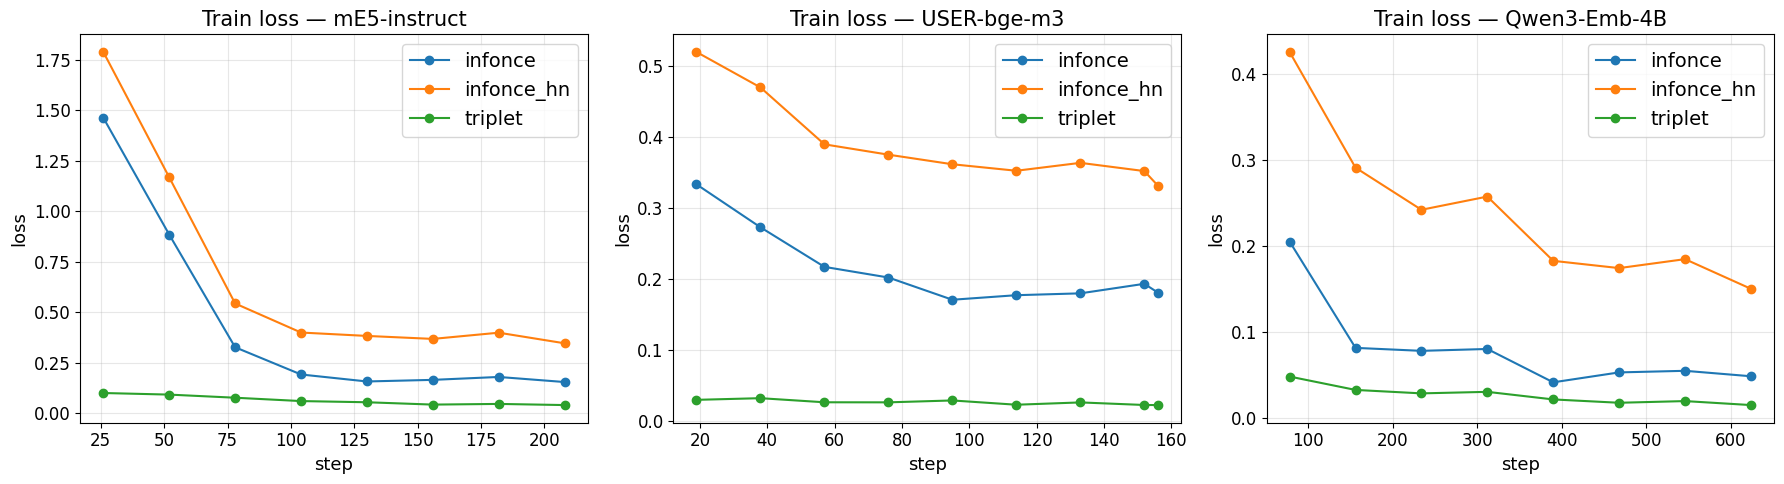

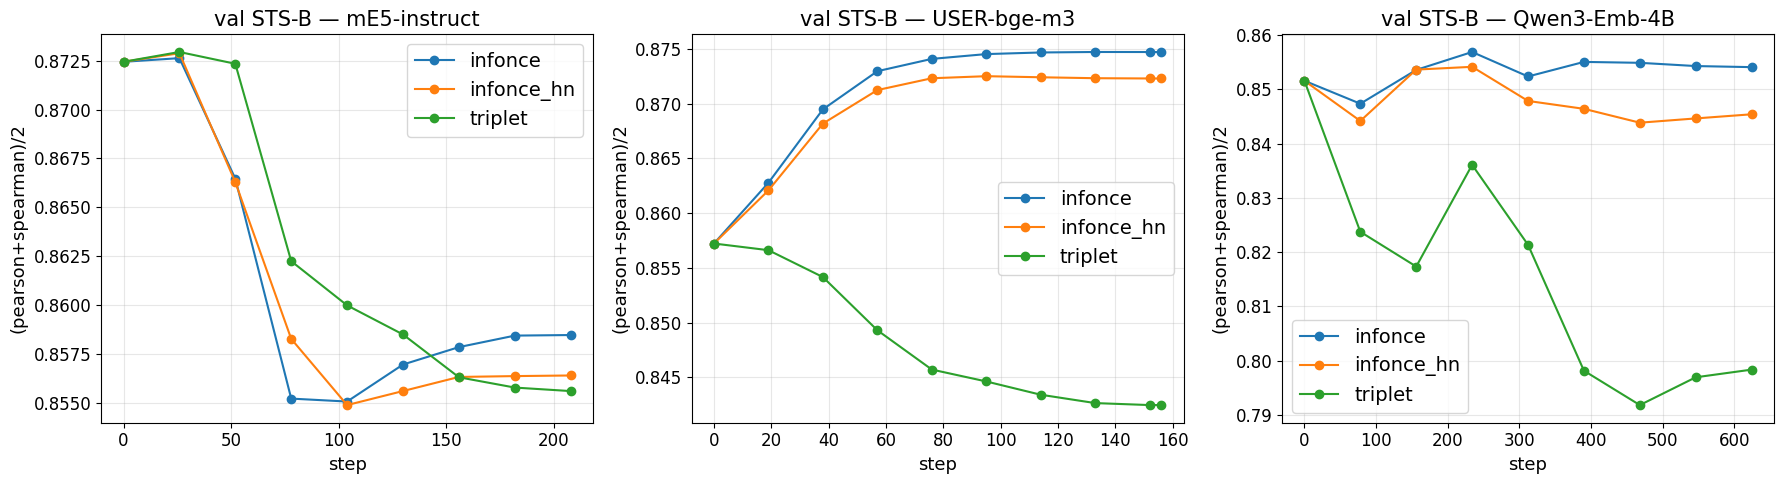

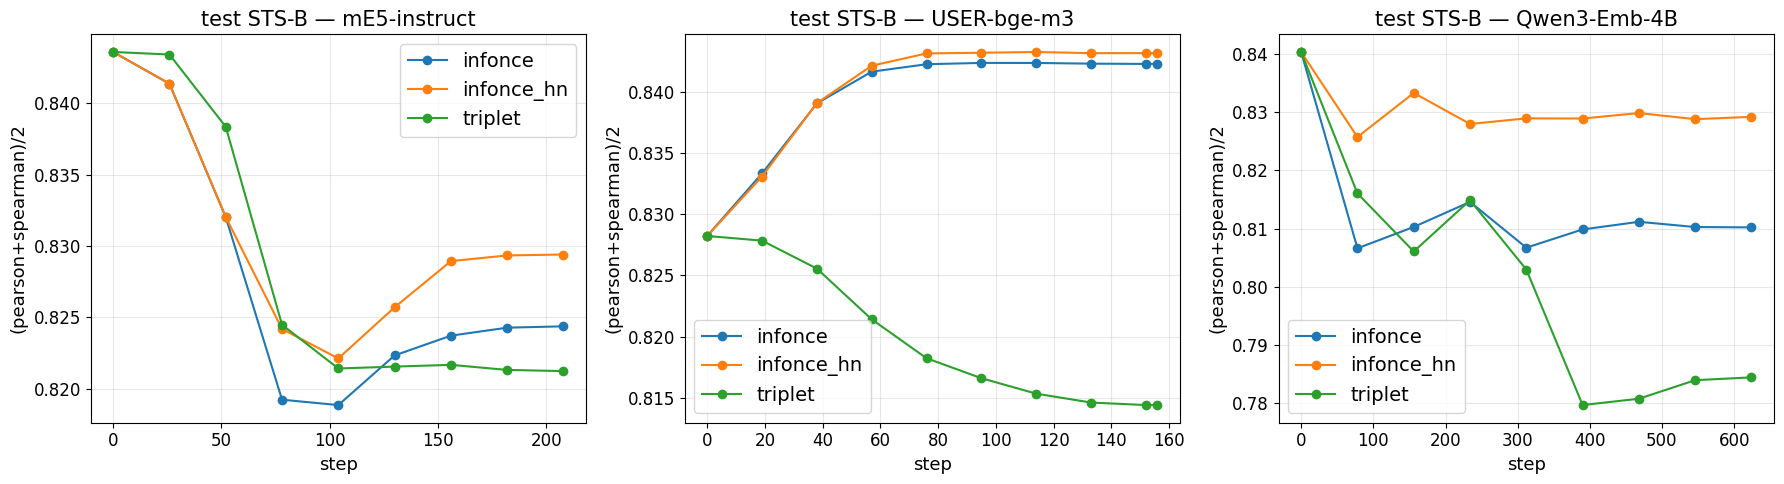

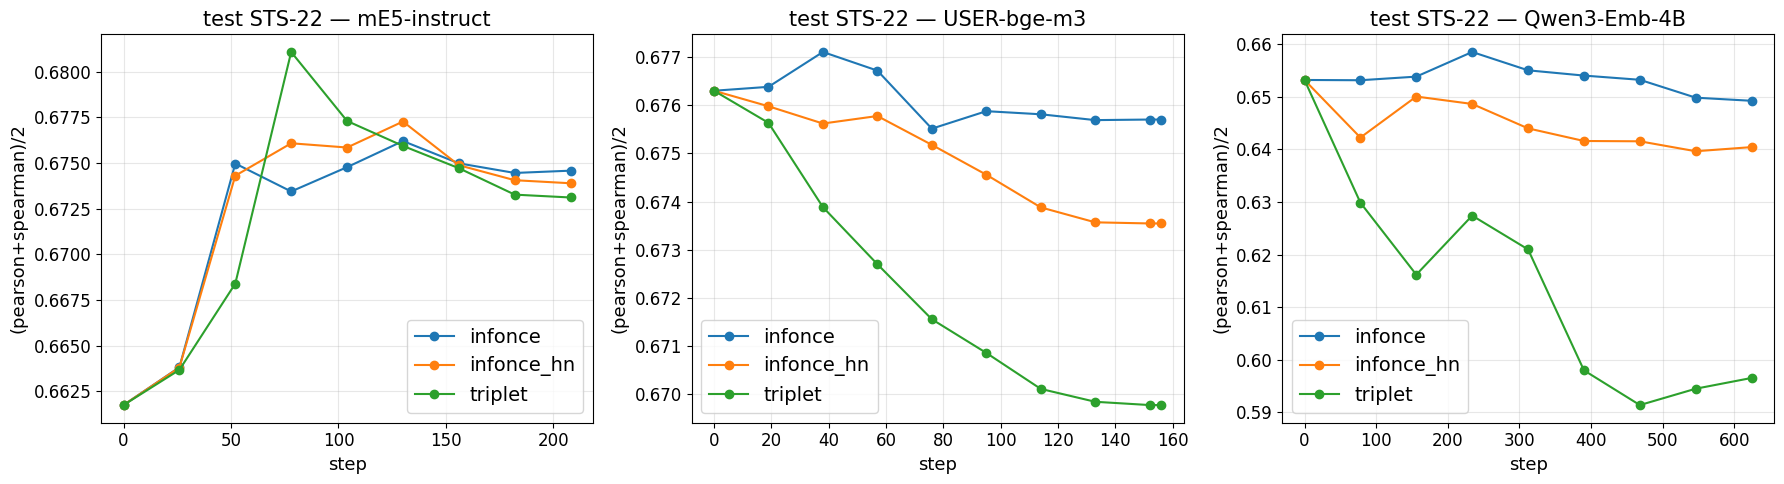

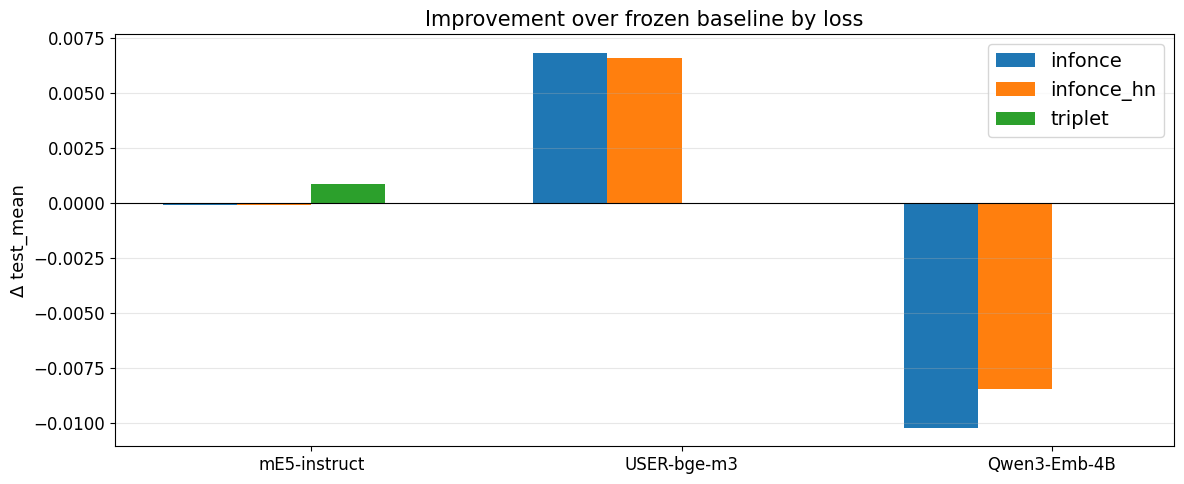

In [ ]:
# 13. Plots — train loss + STS curves per model
LOSS_COLORS = {
    "infonce":     "tab:blue",
    "infonce_hn":  "tab:orange",
    "triplet":     "tab:green",
    "mnr_softmax": "tab:red",
}

def _plot_grid(metric_key, title_prefix, ylabel):
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6*len(MODEL_ORDER), 5))
    if len(MODEL_ORDER) == 1: axes = [axes]
    for ax, model_name in zip(axes, MODEL_ORDER):
        for loss_name in LOSS_ORDER:
            key = (model_name, loss_name)
            if key not in results: continue
            h = results[key]["history"]
            ax.plot(h["steps"], h[metric_key], marker="o",
                    label=loss_name, color=LOSS_COLORS[loss_name])
        ax.set_title(f"{title_prefix} — {model_name}")
        ax.set_xlabel("Итерации"); ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

# train loss
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6*len(MODEL_ORDER), 5))
if len(MODEL_ORDER) == 1: axes = [axes]
for ax, model_name in zip(axes, MODEL_ORDER):
    for loss_name in LOSS_ORDER:
        key = (model_name, loss_name)
        if key not in results: continue
        h = results[key]["history"]
        steps = h["steps"][1:]; losses = h["loss"][1:]
        ax.plot(steps, losses, marker="o", label=loss_name, color=LOSS_COLORS[loss_name])
    ax.set_title(f"Train loss — {model_name}")
    ax.set_xlabel("Итерации"); ax.set_ylabel("loss")
    ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

_plot_grid("val_stsb",   "val STS-B",   "(pearson+spearman)/2")
_plot_grid("test_stsb",  "test STS-B",  "(pearson+spearman)/2")
_plot_grid("test_sts22", "test STS-22", "(pearson+spearman)/2")

# bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
x = np.arange(len(MODEL_ORDER)); w = 0.2
for k, loss_name in enumerate(LOSS_ORDER):
    deltas = []
    for model_name in MODEL_ORDER:
        key = (model_name, loss_name)
        if key not in results: deltas.append(0); continue
        r = results[key]; b = r["baseline"]; f = r["final"]
        d = ((f["test_stsb"] + f["test_sts22"]) - (b["test_stsb"] + b["test_sts22"])) / 2.0
        deltas.append(d)
    ax.bar(x + (k - 1.5) * w, deltas, width=w, label=loss_name, color=LOSS_COLORS[loss_name])
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ test_mean")
ax.set_title("Improvement over frozen baseline by loss")
ax.grid(True, alpha=0.3, axis="y"); ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
# 14. Summary table
rows = []
for model_name in MODEL_ORDER:
    base = BASELINES.get(model_name, {"val_stsb": float("nan"),
                                       "test_stsb": float("nan"),
                                       "test_sts22": float("nan")})
    rows.append({
        "model": model_name, "loss": "baseline",
        "val_stsb": base["val_stsb"], "test_stsb": base["test_stsb"],
        "test_sts22": base["test_sts22"],
        "test_mean": (base["test_stsb"] + base["test_sts22"]) / 2.0
                     if not (pd.isna(base["test_stsb"]) or pd.isna(base["test_sts22"])) else float("nan"),
        "Δval": None, "Δtest_stsb": None, "Δtest_sts22": None, "Δtest_mean": None,
    })
    for loss_name in LOSS_ORDER:
        key = (model_name, loss_name)
        if key not in results: continue
        r = results[key]; f = r["final"]; b = r["baseline"]
        rows.append({
            "model": model_name, "loss": loss_name,
            "val_stsb": f["val_stsb"], "test_stsb": f["test_stsb"],
            "test_sts22": f["test_sts22"],
            "test_mean": (f["test_stsb"] + f["test_sts22"]) / 2.0,
            "Δval":        f["val_stsb"]   - b["val_stsb"],
            "Δtest_stsb":  f["test_stsb"]  - b["test_stsb"],
            "Δtest_sts22": f["test_sts22"] - b["test_sts22"],
            "Δtest_mean":  ((f["test_stsb"]+f["test_sts22"])-(b["test_stsb"]+b["test_sts22"]))/2.0,
        })

df = pd.DataFrame(rows)
pd.set_option("display.precision", 4)
print(df.to_string(index=False))

df.to_csv(os.path.join(HIST_DIR, "summary_loss_compare.csv"), index=False)
with open(os.path.join(HIST_DIR, "summary_loss_compare.json"), "w") as fout:
    json.dump(rows, fout, ensure_ascii=False, indent=2, default=float)
print("\nSaved:", os.path.join(HIST_DIR, "summary_loss_compare.csv"))


       model       loss  val_stsb  test_stsb  test_sts22  test_mean        Δval  Δtest_stsb  Δtest_sts22  Δtest_mean
mE5-instruct   baseline    0.8724     0.8436      0.6617     0.7527         NaN         NaN          NaN         NaN
mE5-instruct    infonce    0.8726     0.8414      0.6638     0.7526  1.8750e-04 -2.2190e-03   2.0700e-03 -7.4542e-05
mE5-instruct infonce_hn    0.8729     0.8414      0.6638     0.7526  4.3937e-04 -2.2204e-03   2.0575e-03 -8.1460e-05
mE5-instruct    triplet    0.8729     0.8434      0.6637     0.7535  5.0268e-04 -1.7682e-04   1.9285e-03  8.7582e-04
 USER-bge-m3   baseline    0.8572     0.8282      0.6763     0.7523         NaN         NaN          NaN         NaN
 USER-bge-m3    infonce    0.8747     0.8424      0.6758     0.7591  1.7458e-02  1.4154e-02  -4.8776e-04  6.8331e-03
 USER-bge-m3 infonce_hn    0.8725     0.8432      0.6746     0.7589  1.5291e-02  1.4989e-02  -1.7408e-03  6.6243e-03
 USER-bge-m3    triplet    0.8572     0.8282      0.6763     0.7

In [ ]:
# 15. Лучшая loss-функция для каждой модели
print("="*70)
print("BEST LOSS PER MODEL (by Δtest_mean over frozen baseline)")
print("="*70)
for model_name in MODEL_ORDER:
    cand = []
    for loss_name in LOSS_ORDER:
        key = (model_name, loss_name)
        if key not in results: continue
        r = results[key]; f = r["final"]; b = r["baseline"]
        d_mean = ((f["test_stsb"]+f["test_sts22"]) - (b["test_stsb"]+b["test_sts22"]))/2.0
        cand.append((loss_name, d_mean, f["val_stsb"], f["test_stsb"], f["test_sts22"]))
    if not cand:
        print(f"{model_name}: (no results)"); continue
    cand.sort(key=lambda x: -x[1])
    print(f"\n{model_name}:")
    for ln, dm, v, ts, s22 in cand:
        flag = "★" if ln == cand[0][0] else " "
        print(f"  {flag} {ln:14s}  Δtest_mean={dm:+.4f}  val={v:.4f}  "
              f"test_stsb={ts:.4f}  test_sts22={s22:.4f}")


BEST LOSS PER MODEL (by Δtest_mean over frozen baseline)

mE5-instruct:
  ★ triplet         Δtest_mean=+0.0009  val=0.8729  test_stsb=0.8434  test_sts22=0.6637
    infonce         Δtest_mean=-0.0001  val=0.8726  test_stsb=0.8414  test_sts22=0.6638
    infonce_hn      Δtest_mean=-0.0001  val=0.8729  test_stsb=0.8414  test_sts22=0.6638

USER-bge-m3:
  ★ infonce         Δtest_mean=+0.0068  val=0.8747  test_stsb=0.8424  test_sts22=0.6758
    infonce_hn      Δtest_mean=+0.0066  val=0.8725  test_stsb=0.8432  test_sts22=0.6746
    triplet         Δtest_mean=-0.0000  val=0.8572  test_stsb=0.8282  test_sts22=0.6763

Qwen3-Emb-4B:
  ★ triplet         Δtest_mean=+0.0000  val=0.8512  test_stsb=0.8404  test_sts22=0.6531
    infonce_hn      Δtest_mean=-0.0085  val=0.8541  test_stsb=0.8280  test_sts22=0.6486
    infonce         Δtest_mean=-0.0102  val=0.8569  test_stsb=0.8146  test_sts22=0.6585
